# Combined Cluster Analysis with CDOM Slopes

This notebook:
1. Loads K-Means and DBSCAN clustering models
2. Applies both models to the same time period
3. Creates binary maps from both clustering methods
4. Calculates CDOM spectral slopes for the same period
5. Computes average CDOM slopes for different cluster categories

**Analysis Categories:**
- K-Means binary (0 vs 1)
- DBSCAN binary (0 vs 1)
- Combined binary (0 vs 1)

**Time Period:** July 2009 (matching other analyses)

## 1. Setup and Imports

In [3]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from scipy.stats import binned_statistic_2d
from scipy.interpolate import RegularGridInterpolator
import pickle
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm, rgb2hex
import cmocean

import sys
sys.dont_write_bytecode = True
sys.path.append(os.path.abspath(".."))

from pipelines.l3_pipeline import L3DatasetLoader
from pipelines.l2_pipeline import L2DatasetLoader, GPUDataExtractor

import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Configuration

In [4]:
# Time period for analysis
apply_year = 2009
apply_start = '2009-07-01'
apply_end = '2009-07-31'

# Data directories
sst_base_pattern = r"E:\satdata\MUR-JPL-L4-GLOB-v4.1_Texas Louisiana Shelf_{year}-06-01_{year}-11-30"
chlor_base_pattern = r"E:\satdata\Texas Louisiana Shelf_{year}-06-01_{year}-11-30"

# Model paths
kmeans_model_path = r"E:\satdata\Custom\kmeans_model_2010_2011_weekly.pkl"
dbscan_model_path = r"E:\satdata\Custom\dbscan_model_optimal_2005_2011.pkl"

# Variables
sst_var = 'analysed_sst'
chlor_var = 'chlor_a'
chlor_group = 'geophysical_data'
rrs_vars_list = ['Rrs_443', 'Rrs_547']  # For CDOM calculation

# CDOM slope configuration
SLOPE_TYPE = 'S300_600'  # Options: 'S275_295' or 'S300_600'

# MLR Coefficients for S_300:600
S300_600_COEFFS = {
    'B0': -3.640,
    'B1': 0.186,
    'B2': -0.146
}

# MLR Coefficients for S_275:295
S275_295_COEFFS = {
    'B0': -3.258,
    'B1': 0.336,
    'B2': -0.279
}

print(f"Configuration loaded for: {apply_start} to {apply_end}")
print(f"CDOM slope type: {SLOPE_TYPE}")

Configuration loaded for: 2009-07-01 to 2009-07-31
CDOM slope type: S300_600


## 3. Load Clustering Models

In [5]:
# Load K-Means model
print("Loading K-Means model...")
with open(kmeans_model_path, 'rb') as f:
    kmeans_data = pickle.load(f)

kmeans = kmeans_data['kmeans_model']
kmeans_scaler = kmeans_data['scaler']
lat_centers = kmeans_data['lat_centers']
lon_centers = kmeans_data['lon_centers']
lat_edges = kmeans_data['lat_edges']
lon_edges = kmeans_data['lon_edges']
bbox = kmeans_data['bbox']
grid_shape = kmeans_data['grid_shape']

lon_min, lon_max, lat_min, lat_max = bbox
lat_bins, lon_bins = grid_shape

print(f"✓ K-Means loaded: {kmeans_data['n_clusters']} clusters")

# Load DBSCAN model
print("\nLoading DBSCAN model...")
with open(dbscan_model_path, 'rb') as f:
    dbscan_data = pickle.load(f)

dbscan = dbscan_data['dbscan_model']
dbscan_scaler = dbscan_data['scaler']

print(f"✓ DBSCAN loaded: eps={dbscan_data['eps']:.4f}, min_samples={dbscan_data['min_samples']}")
print(f"\nBounding box: [{lon_min}, {lat_min}] to [{lon_max}, {lat_max}]")
print(f"Grid: {lat_bins} x {lon_bins}")

Loading K-Means model...
✓ K-Means loaded: 3 clusters

Loading DBSCAN model...
✓ DBSCAN loaded: eps=0.0142, min_samples=4

Bounding box: [-94.0, 27.5] to [-88.0, 30.5]
Grid: 200 x 300


## 4. Load and Process SST Data

In [6]:
print("=" * 80)
print("LOADING SST DATA")
print("=" * 80)

sst_dir = sst_base_pattern.format(year=apply_year)
all_sst_files = sorted(glob.glob(os.path.join(sst_dir, '*.nc')))
print(f"Total SST files in {apply_year}: {len(all_sst_files)}")

# Filter by date
sst_files = []
for sst_file in all_sst_files:
    try:
        with xr.open_dataset(sst_file) as ds:
            file_time = pd.to_datetime(ds.time.values[0])
            if pd.Timestamp(apply_start) <= file_time <= pd.Timestamp(apply_end):
                sst_files.append(sst_file)
    except:
        continue

print(f"Files in period: {len(sst_files)}")

# Load datasets
sst_loader = L3DatasetLoader(variables=[sst_var], bbox=(lon_min, lon_max, lat_min, lat_max))
sst_datasets = sst_loader.load_multiple(sst_files)

# Process SST
sst_list = []
for ds in sst_datasets:
    sst_k = ds[sst_var].values.squeeze()
    sst_c = sst_k - 273.15
    sst_c[(sst_c < -2) | (sst_c > 35)] = np.nan
    sst_list.append(sst_c)

sst_mean = np.nanmean(np.stack(sst_list, axis=0), axis=0)
lat_sst = sst_datasets[0]['lat'].values
lon_sst = sst_datasets[0]['lon'].values

print(f"SST range: {np.nanmin(sst_mean):.2f} to {np.nanmax(sst_mean):.2f} °C")
print(f"Valid pixels: {np.sum(~np.isnan(sst_mean))}")

LOADING SST DATA
Total SST files in 2009: 184
Files in period: 30
SST range: 28.15 to 30.42 °C
Valid pixels: 137002


## 5. Load and Process Chlorophyll Data

In [7]:
print("=" * 80)
print("LOADING CHLOROPHYLL DATA")
print("=" * 80)

chlor_dir = chlor_base_pattern.format(year=apply_year)
all_chlor_files = glob.glob(os.path.join(chlor_dir, '**', '*.nc'), recursive=True)
print(f"Total chlorophyll files in {apply_year}: {len(all_chlor_files)}")

# Filter by date
chlor_files = []
for chlor_file in all_chlor_files:
    filename = os.path.basename(chlor_file)
    try:
        if 'AQUA_MODIS' in filename or 'MODIS' in filename:
            parts = filename.split('.')
            if len(parts) > 1:
                date_str = parts[1][:8]
                file_date = pd.to_datetime(date_str, format='%Y%m%d')
                if pd.Timestamp(apply_start) <= file_date <= pd.Timestamp(apply_end):
                    chlor_files.append(chlor_file)
    except:
        continue

print(f"Files in period: {len(chlor_files)}")

if len(chlor_files) > 0:
    chlor_loader = L2DatasetLoader(variables=[chlor_var], group=chlor_group)
    chlor_datasets = chlor_loader.load_multiple(chlor_files)
    
    try:
        extractor = GPUDataExtractor(variables=[chlor_var])
        lon_chlor, lat_chlor, chlor_data = extractor.extract(chlor_datasets)
        chlor_flat = chlor_data[chlor_var]
        print(f"GPU extraction: {len(chlor_flat)} points")
    except Exception as e:
        print(f"GPU failed, using CPU...")
        all_lons, all_lats, all_chlor = [], [], []
        for ds in chlor_datasets:
            lat = ds['lat'].values.flatten()
            lon = ds['lon'].values.flatten()
            chlor = ds[chlor_var].values.flatten()
            valid = (~np.isnan(lat) & ~np.isnan(lon) & ~np.isnan(chlor) & (chlor > 0))
            all_lats.extend(lat[valid])
            all_lons.extend(lon[valid])
            all_chlor.extend(chlor[valid])
        lat_chlor = np.array(all_lats)
        lon_chlor = np.array(all_lons)
        chlor_flat = np.array(all_chlor)
        print(f"CPU extraction: {len(chlor_flat)} points")
else:
    print("⚠ No chlorophyll files found")
    chlor_flat = np.array([])
    lat_chlor = np.array([])
    lon_chlor = np.array([])

LOADING CHLOROPHYLL DATA
Total chlorophyll files in 2009: 284
Files in period: 50
GPU extraction: 14552214 points


## 6. Load and Process CDOM Rrs Data

In [8]:
print("=" * 80)
print("LOADING RRS DATA FOR CDOM")
print("=" * 80)

# Use same chlorophyll files for Rrs data
if len(chlor_files) > 0:
    rrs_loader = L2DatasetLoader(variables=rrs_vars_list, group=chlor_group)
    rrs_datasets = rrs_loader.load_multiple(chlor_files)
    
    try:
        rrs_extractor = GPUDataExtractor(variables=rrs_vars_list)
        lon_rrs, lat_rrs, rrs_data = rrs_extractor.extract(rrs_datasets)
        rrs_443 = rrs_data['Rrs_443']
        rrs_547 = rrs_data['Rrs_547']
        print(f"GPU extraction: {len(lon_rrs)} RRS points")
    except Exception as e:
        print(f"GPU failed, using CPU...")
        all_lons, all_lats, all_443, all_547 = [], [], [], []
        for ds in rrs_datasets:
            lat = ds['lat'].values.flatten()
            lon = ds['lon'].values.flatten()
            r443 = ds['Rrs_443'].values.flatten()
            r547 = ds['Rrs_547'].values.flatten()
            valid = (~np.isnan(lat) & ~np.isnan(lon) & ~np.isnan(r443) & ~np.isnan(r547) & 
                     (r443 > 0) & (r547 > 0))
            all_lats.extend(lat[valid])
            all_lons.extend(lon[valid])
            all_443.extend(r443[valid])
            all_547.extend(r547[valid])
        lat_rrs = np.array(all_lats)
        lon_rrs = np.array(all_lons)
        rrs_443 = np.array(all_443)
        rrs_547 = np.array(all_547)
        print(f"CPU extraction: {len(lon_rrs)} RRS points")
else:
    print("⚠ No RRS files found")
    lon_rrs = np.array([])
    lat_rrs = np.array([])
    rrs_443 = np.array([])
    rrs_547 = np.array([])

LOADING RRS DATA FOR CDOM
GPU extraction: 14569607 RRS points


## 7. Grid All Data

In [9]:
print("=" * 80)
print("GRIDDING DATA")
print("=" * 80)

# Bin chlorophyll
clip_mask = ((lon_chlor >= lon_min) & (lon_chlor <= lon_max) &
             (lat_chlor >= lat_min) & (lat_chlor <= lat_max))

chlor_binned, _, _, _ = binned_statistic_2d(
    lat_chlor[clip_mask], lon_chlor[clip_mask], chlor_flat[clip_mask],
    statistic='mean',
    bins=[lat_bins, lon_bins],
    range=[[lat_min, lat_max], [lon_min, lon_max]]
)

print(f"Valid chlorophyll pixels: {np.sum(~np.isnan(chlor_binned))}")

# Interpolate SST to grid
sst_interpolator = RegularGridInterpolator(
    (lat_sst, lon_sst), sst_mean,
    method='linear', bounds_error=False, fill_value=np.nan
)

lon_grid, lat_grid = np.meshgrid(lon_centers, lat_centers)
points = np.column_stack([lat_grid.ravel(), lon_grid.ravel()])
sst_regridded = sst_interpolator(points).reshape(chlor_binned.shape)

print(f"Valid SST pixels: {np.sum(~np.isnan(sst_regridded))}")

# Bin CDOM Rrs data
if len(lon_rrs) > 0:
    clip_mask_rrs = ((lon_rrs >= lon_min) & (lon_rrs <= lon_max) &
                     (lat_rrs >= lat_min) & (lat_rrs <= lat_max))
    
    rrs_443_binned, _, _, _ = binned_statistic_2d(
        lat_rrs[clip_mask_rrs], lon_rrs[clip_mask_rrs], rrs_443[clip_mask_rrs],
        statistic='mean',
        bins=[lat_bins, lon_bins],
        range=[[lat_min, lat_max], [lon_min, lon_max]]
    )
    
    rrs_547_binned, _, _, _ = binned_statistic_2d(
        lat_rrs[clip_mask_rrs], lon_rrs[clip_mask_rrs], rrs_547[clip_mask_rrs],
        statistic='mean',
        bins=[lat_bins, lon_bins],
        range=[[lat_min, lat_max], [lon_min, lon_max]]
    )
    
    print(f"Valid Rrs_443 pixels: {np.sum(~np.isnan(rrs_443_binned))}")
    print(f"Valid Rrs_547 pixels: {np.sum(~np.isnan(rrs_547_binned))}")
else:
    rrs_443_binned = np.full(chlor_binned.shape, np.nan)
    rrs_547_binned = np.full(chlor_binned.shape, np.nan)
    print("⚠ No RRS data to bin")

GRIDDING DATA
Valid chlorophyll pixels: 44164
Valid SST pixels: 44898
Valid Rrs_443 pixels: 44247
Valid Rrs_547 pixels: 44247


## 8. Calculate CDOM Spectral Slopes

In [10]:
print("=" * 80)
print("CALCULATING CDOM SPECTRAL SLOPES")
print("=" * 80)

# Initialize CDOM slope array
cdom_slope = np.full(chlor_binned.shape, np.nan)

# Get coefficients
if SLOPE_TYPE == 'S275_295':
    coeffs = S275_295_COEFFS
    slope_name = "S_275:295"
elif SLOPE_TYPE == 'S300_600':
    coeffs = S300_600_COEFFS
    slope_name = "S_300:600"
else:
    print(f"Unknown slope type '{SLOPE_TYPE}', using S_300:600")
    coeffs = S300_600_COEFFS
    slope_name = "S_300:600"

# Calculate slopes
valid_mask = (~np.isnan(rrs_443_binned) & ~np.isnan(rrs_547_binned) & 
              (rrs_443_binned > 0) & (rrs_547_binned > 0))

if np.any(valid_mask):
    ln_rrs_443 = np.log(rrs_443_binned[valid_mask])
    ln_rrs_547 = np.log(rrs_547_binned[valid_mask])
    
    ln_slope = (coeffs['B0'] + coeffs['B1'] * ln_rrs_443 + coeffs['B2'] * ln_rrs_547)
    slope_values = np.exp(ln_slope)
    
    cdom_slope[valid_mask] = slope_values
    
    print(f"✓ CDOM {slope_name} calculation complete")
    valid_slopes = cdom_slope[~np.isnan(cdom_slope)]
    print(f"  Valid pixels: {len(valid_slopes):,}")
    print(f"  Range: [{np.min(valid_slopes):.6f}, {np.max(valid_slopes):.6f}] nm⁻¹")
    print(f"  Mean: {np.mean(valid_slopes):.6f} nm⁻¹")
    print(f"  Std: {np.std(valid_slopes):.6f} nm⁻¹")
else:
    print("⚠ No valid RRS data for CDOM calculation")

CALCULATING CDOM SPECTRAL SLOPES
✓ CDOM S_300:600 calculation complete
  Valid pixels: 44,106
  Range: [0.008459, 0.032046] nm⁻¹
  Mean: 0.021626 nm⁻¹
  Std: 0.002248 nm⁻¹


## 9. Apply Clustering Models

In [11]:
print("=" * 80)
print("APPLYING CLUSTERING MODELS")
print("=" * 80)

# Normalize SST for K-Means (weekly normalization)
sst_min_period = np.nanmin(sst_regridded)
sst_max_period = np.nanmax(sst_regridded)
sst_range_period = sst_max_period - sst_min_period

sst_normalized = (sst_regridded - sst_min_period) / sst_range_period if sst_range_period > 0 else sst_regridded * 0

print(f"SST normalized: [{np.nanmin(sst_normalized):.4f}, {np.nanmax(sst_normalized):.4f}]")

# Prepare features
valid_mask_cluster = ~np.isnan(sst_normalized) & ~np.isnan(chlor_binned)
n_valid = np.sum(valid_mask_cluster)
print(f"Pixels with both SST and chlorophyll: {n_valid}")

if n_valid > 0:
    sst_valid = sst_normalized[valid_mask_cluster]
    sst_actual_valid = sst_regridded[valid_mask_cluster]
    chlor_valid = chlor_binned[valid_mask_cluster]
    
    # K-Means clustering (normalized SST)
    kmeans_features = np.column_stack([sst_valid, np.log10(chlor_valid)])
    kmeans_features_scaled = kmeans_scaler.transform(kmeans_features)
    kmeans_labels = kmeans.predict(kmeans_features_scaled)
    
    print(f"✓ K-Means applied: {len(set(kmeans_labels))} clusters found")
    
    # DBSCAN clustering (actual SST)
    dbscan_features = np.column_stack([sst_actual_valid, np.log10(chlor_valid)])
    dbscan_features_scaled = dbscan_scaler.transform(dbscan_features)
    dbscan_labels = dbscan.fit_predict(dbscan_features_scaled)
    
    n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_dbscan_noise = np.sum(dbscan_labels == -1)
    print(f"✓ DBSCAN applied: {n_dbscan_clusters} clusters, {n_dbscan_noise} noise points")
    
    # Create cluster maps
    kmeans_map = np.full(chlor_binned.shape, np.nan)
    kmeans_map[valid_mask_cluster] = kmeans_labels
    
    dbscan_map = np.full(chlor_binned.shape, np.nan)
    dbscan_map[valid_mask_cluster] = dbscan_labels
else:
    print("⚠ No valid data for clustering")
    kmeans_labels = np.array([])
    dbscan_labels = np.array([])
    kmeans_map = np.full(chlor_binned.shape, np.nan)
    dbscan_map = np.full(chlor_binned.shape, np.nan)

APPLYING CLUSTERING MODELS
SST normalized: [0.0000, 1.0000]
Pixels with both SST and chlorophyll: 43721
✓ K-Means applied: 3 clusters found
✓ DBSCAN applied: 980 clusters, 9192 noise points


## 10. Create Binary Maps

In [12]:
print("=" * 80)
print("CREATING BINARY MAPS")
print("=" * 80)

if n_valid > 0:
    # K-Means binary: clusters 0,2 → 0; cluster 1 → 1
    kmeans_binary = np.full(chlor_binned.shape, np.nan)
    for i, label_val in enumerate(kmeans_labels):
        if label_val in [0, 2]:
            kmeans_binary.flat[np.where(valid_mask_cluster.flat)[0][i]] = 0
        elif label_val == 1:
            kmeans_binary.flat[np.where(valid_mask_cluster.flat)[0][i]] = 1
    
    kmeans_0 = np.sum(kmeans_binary == 0)
    kmeans_1 = np.sum(kmeans_binary == 1)
    print(f"K-Means binary:")
    print(f"  0 (clusters 0,2): {kmeans_0} pixels")
    print(f"  1 (cluster 1): {kmeans_1} pixels")
    
    # DBSCAN binary: clusters 400-1000 → 1; clusters <400 → 0
    dbscan_binary = np.full(chlor_binned.shape, np.nan)
    for i, label_val in enumerate(dbscan_labels):
        if 400 <= label_val <= 1000:
            dbscan_binary.flat[np.where(valid_mask_cluster.flat)[0][i]] = 1
        elif label_val < 400:
            dbscan_binary.flat[np.where(valid_mask_cluster.flat)[0][i]] = 0
    
    dbscan_0 = np.sum(dbscan_binary == 0)
    dbscan_1 = np.sum(dbscan_binary == 1)
    print(f"\nDBSCAN binary:")
    print(f"  0 (clusters <400): {dbscan_0} pixels")
    print(f"  1 (clusters 400-1000): {dbscan_1} pixels")
    
    # Combined binary: multiply the two
    combined_binary = kmeans_binary * dbscan_binary
    
    combined_0 = np.sum(combined_binary == 0)
    combined_1 = np.sum(combined_binary == 1)
    print(f"\nCombined binary (K-Means × DBSCAN):")
    print(f"  0: {combined_0} pixels")
    print(f"  1: {combined_1} pixels")
else:
    kmeans_binary = np.full(chlor_binned.shape, np.nan)
    dbscan_binary = np.full(chlor_binned.shape, np.nan)
    combined_binary = np.full(chlor_binned.shape, np.nan)
    print("⚠ No valid data for binary maps")

CREATING BINARY MAPS
K-Means binary:
  0 (clusters 0,2): 5201 pixels
  1 (cluster 1): 38520 pixels

DBSCAN binary:
  0 (clusters <400): 39403 pixels
  1 (clusters 400-1000): 4318 pixels

Combined binary (K-Means × DBSCAN):
  0: 40663 pixels
  1: 3058 pixels


## 11. Calculate Average CDOM Slopes by Cluster Category

In [13]:
print("\n" + "=" * 80)
print(f"AVERAGE CDOM SLOPES BY CLUSTER CATEGORY ({slope_name})")
print("=" * 80)

def calculate_stats(data_array, binary_map, category_value, category_name):
    """Calculate statistics for CDOM slopes in a specific category"""
    mask = (binary_map == category_value) & ~np.isnan(data_array)
    values = data_array[mask]
    
    if len(values) > 0:
        print(f"\n{category_name}:")
        print(f"  N = {len(values):,} pixels")
        print(f"  Mean = {np.mean(values):.6f} nm⁻¹")
        print(f"  Std = {np.std(values):.6f} nm⁻¹")
        print(f"  Median = {np.median(values):.6f} nm⁻¹")
        print(f"  Min = {np.min(values):.6f} nm⁻¹")
        print(f"  Max = {np.max(values):.6f} nm⁻¹")
        return values
    else:
        print(f"\n{category_name}: No valid data")
        return np.array([])

# K-Means binary analysis
print("\n" + "-" * 80)
print("K-MEANS BINARY MAP")
print("-" * 80)
kmeans_0_slopes = calculate_stats(cdom_slope, kmeans_binary, 0, "K-Means Category 0 (Clusters 0,2)")
kmeans_1_slopes = calculate_stats(cdom_slope, kmeans_binary, 1, "K-Means Category 1 (Cluster 1)")

# DBSCAN binary analysis
print("\n" + "-" * 80)
print("DBSCAN BINARY MAP")
print("-" * 80)
dbscan_0_slopes = calculate_stats(cdom_slope, dbscan_binary, 0, "DBSCAN Category 0 (Clusters <400)")
dbscan_1_slopes = calculate_stats(cdom_slope, dbscan_binary, 1, "DBSCAN Category 1 (Clusters 400-1000)")

# Combined binary analysis
print("\n" + "-" * 80)
print("COMBINED BINARY MAP (K-Means × DBSCAN)")
print("-" * 80)
combined_0_slopes = calculate_stats(cdom_slope, combined_binary, 0, "Combined Category 0")
combined_1_slopes = calculate_stats(cdom_slope, combined_binary, 1, "Combined Category 1 (Both Models Agree)")

print("\n" + "=" * 80)


AVERAGE CDOM SLOPES BY CLUSTER CATEGORY (S_300:600)

--------------------------------------------------------------------------------
K-MEANS BINARY MAP
--------------------------------------------------------------------------------

K-Means Category 0 (Clusters 0,2):
  N = 5,193 pixels
  Mean = 0.019779 nm⁻¹
  Std = 0.001234 nm⁻¹
  Median = 0.019791 nm⁻¹
  Min = 0.008459 nm⁻¹
  Max = 0.023037 nm⁻¹

K-Means Category 1 (Cluster 1):
  N = 38,490 pixels
  Mean = 0.021919 nm⁻¹
  Std = 0.002194 nm⁻¹
  Median = 0.021769 nm⁻¹
  Min = 0.009138 nm⁻¹
  Max = 0.027765 nm⁻¹

--------------------------------------------------------------------------------
DBSCAN BINARY MAP
--------------------------------------------------------------------------------

DBSCAN Category 0 (Clusters <400):
  N = 39,366 pixels
  Mean = 0.021931 nm⁻¹
  Std = 0.002130 nm⁻¹
  Median = 0.021738 nm⁻¹
  Min = 0.008459 nm⁻¹
  Max = 0.027765 nm⁻¹

DBSCAN Category 1 (Clusters 400-1000):
  N = 4,317 pixels
  Mean = 0.019237 n

## 12. Visualize Binary Maps

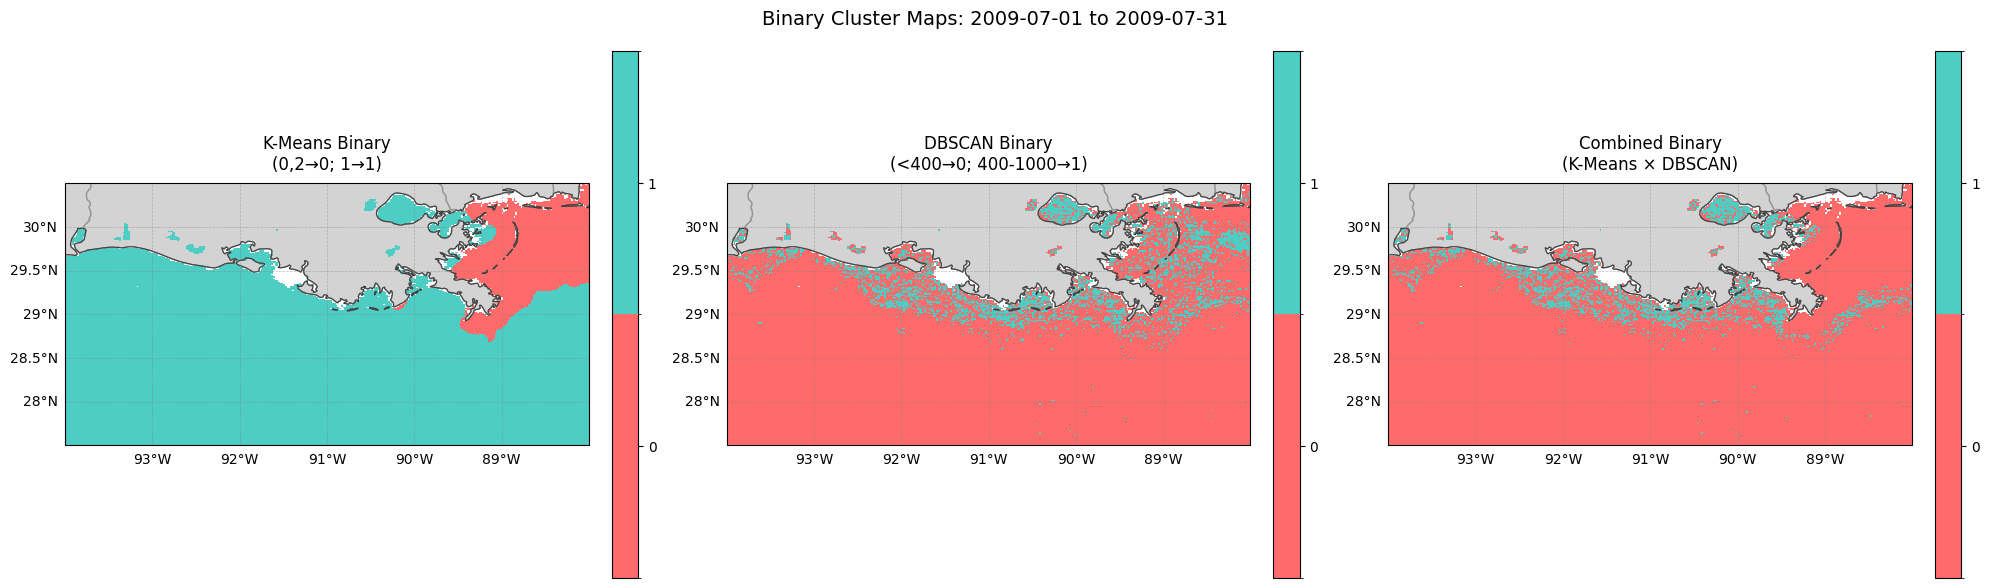

In [14]:
if n_valid > 0:
    # Binary colormap
    binary_cmap = ListedColormap(['#FF6B6B', '#4ECDC4'])  # Red=0, Teal=1
    binary_norm = BoundaryNorm([0, 0.5, 1], binary_cmap.N)
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    
    maps_to_plot = [
        (kmeans_binary, 'K-Means Binary\n(0,2→0; 1→1)', axes[0]),
        (dbscan_binary, 'DBSCAN Binary\n(<400→0; 400-1000→1)', axes[1]),
        (combined_binary, 'Combined Binary\n(K-Means × DBSCAN)', axes[2])
    ]
    
    for data, title, ax in maps_to_plot:
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        
        plot = ax.pcolormesh(lon_edges, lat_edges, data, 
                             cmap=binary_cmap, norm=binary_norm,
                             shading='auto', transform=ccrs.PlateCarree())
        
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='gray', alpha=0.5)
        
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = gl.right_labels = False
        
        cbar = plt.colorbar(plot, ax=ax, fraction=0.046, pad=0.04, ticks=[0.25, 0.75])
        cbar.ax.set_yticklabels(['0', '1'])
        
        ax.set_title(title, fontsize=12, pad=10)
    
    plt.suptitle(f'Binary Cluster Maps: {apply_start} to {apply_end}', fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()
else:
    print("No data to visualize")

## 13. Visualize CDOM Slopes Map

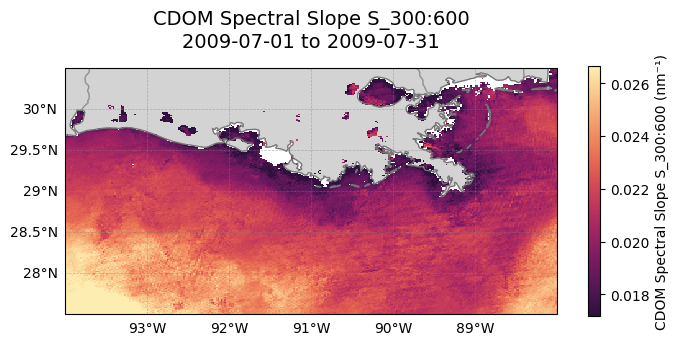

In [15]:
if np.any(~np.isnan(cdom_slope)):
    fig = plt.figure(figsize=(7, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    # Calculate color scale
    valid_cdom = cdom_slope[~np.isnan(cdom_slope)]
    vmin = np.percentile(valid_cdom, 2)
    vmax = np.percentile(valid_cdom, 98)
    
    # Plot
    raster = ax.pcolormesh(lon_edges, lat_edges, cdom_slope,
                           cmap=cmocean.cm.matter_r, shading='auto',
                           transform=ccrs.PlateCarree(),
                           vmin=vmin, vmax=vmax)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='dimgray')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
    ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='gray', alpha=0.5)
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = gl.right_labels = False
    
    cbar = plt.colorbar(raster, label=f'CDOM Spectral Slope {slope_name} (nm⁻¹)', shrink=0.7)
    
    plt.title(f'CDOM Spectral Slope {slope_name}\n{apply_start} to {apply_end}', 
              fontsize=14, pad=15)
    
    plt.tight_layout()
    plt.show()
else:
    print("No CDOM slope data to visualize")

## 14. Statistical Comparison

In [16]:
# Compare the distributions
from scipy import stats

print("\n" + "=" * 80)
print("STATISTICAL COMPARISONS (T-TESTS)")
print("=" * 80)

# K-Means: 0 vs 1
if len(kmeans_0_slopes) > 0 and len(kmeans_1_slopes) > 0:
    t_stat, p_val = stats.ttest_ind(kmeans_0_slopes, kmeans_1_slopes)
    print(f"\nK-Means (0 vs 1):")
    print(f"  t-statistic = {t_stat:.4f}")
    print(f"  p-value = {p_val:.6e}")
    print(f"  Significant at α=0.05: {'Yes' if p_val < 0.05 else 'No'}")

# DBSCAN: 0 vs 1
if len(dbscan_0_slopes) > 0 and len(dbscan_1_slopes) > 0:
    t_stat, p_val = stats.ttest_ind(dbscan_0_slopes, dbscan_1_slopes)
    print(f"\nDBSCAN (0 vs 1):")
    print(f"  t-statistic = {t_stat:.4f}")
    print(f"  p-value = {p_val:.6e}")
    print(f"  Significant at α=0.05: {'Yes' if p_val < 0.05 else 'No'}")

# Combined: 0 vs 1
if len(combined_0_slopes) > 0 and len(combined_1_slopes) > 0:
    t_stat, p_val = stats.ttest_ind(combined_0_slopes, combined_1_slopes)
    print(f"\nCombined (0 vs 1):")
    print(f"  t-statistic = {t_stat:.4f}")
    print(f"  p-value = {p_val:.6e}")
    print(f"  Significant at α=0.05: {'Yes' if p_val < 0.05 else 'No'}")

print("\n" + "=" * 80)


STATISTICAL COMPARISONS (T-TESTS)

K-Means (0 vs 1):
  t-statistic = -68.8469
  p-value = 0.000000e+00
  Significant at α=0.05: Yes

DBSCAN (0 vs 1):
  t-statistic = 81.4576
  p-value = 0.000000e+00
  Significant at α=0.05: Yes

Combined (0 vs 1):
  t-statistic = 76.9900
  p-value = 0.000000e+00
  Significant at α=0.05: Yes



## 15. Summary

This notebook demonstrates:
1. Loading and applying pre-trained clustering models (K-Means and DBSCAN)
2. Creating binary classification maps from both methods
3. Calculating CDOM spectral slopes using Mannino et al. algorithm
4. Computing average CDOM slopes for different cluster categories
5. Statistical comparison of CDOM slopes between categories

The analysis reveals how different water mass classifications (from clustering) correspond to variations in CDOM optical properties.

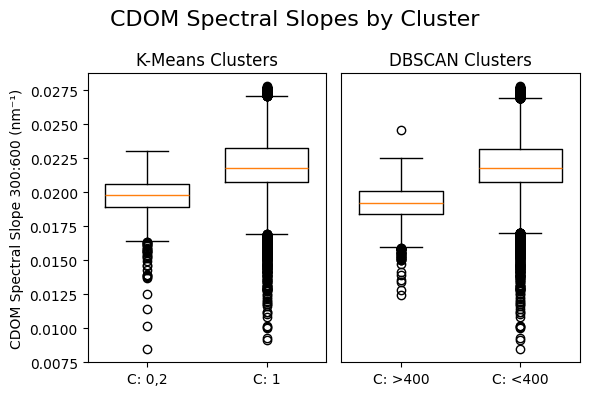

In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(6, 4))  # Wider figure for wider boxes

# K-Means boxplot
axes[0].boxplot([kmeans_0_slopes, kmeans_1_slopes], labels=["C: 0,2", "C: 1"], widths=0.7)
axes[0].set_title("K-Means Clusters")
axes[0].set_ylabel(f"CDOM Spectral Slope 300:600 (nm⁻¹)")

# DBSCAN boxplot
axes[1].boxplot([dbscan_1_slopes, dbscan_0_slopes], labels=["C: >400", "C: <400"], widths=0.7)
axes[1].set_title("DBSCAN Clusters")
axes[1].set_ylabel("")
axes[1].tick_params(axis='y', left=False, labelleft=False)

plt.suptitle("CDOM Spectral Slopes by Cluster", fontsize=16)
plt.tight_layout()
plt.show()

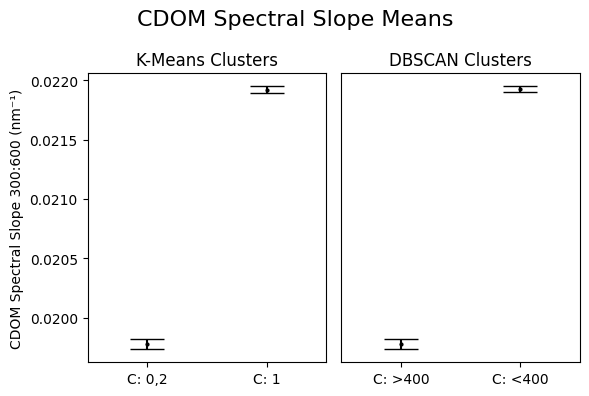

In [61]:
# Plot means and 95% confidence intervals for each cluster (no boxplot, same style)
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def mean_confidence_interval(data, confidence=0.99):
    a = np.array(data)
    n = len(a)
    if n == 0:
        return np.nan, np.nan
    m, se = np.mean(a), stats.sem(a)
    h = se * stats.t.ppf((1 + confidence) / 2., n-1)
    return m, h

fig, axes = plt.subplots(1, 2, figsize=(6, 4))

# K-Means means and CI
means = []
cis = []
labels = ["C: 0,2", "C: 1"]
x_kmeans = [0.25, 0.75]  # Make error bars nearly overlap
for data in [kmeans_0_slopes, kmeans_1_slopes]:
    mean, ci = mean_confidence_interval(data)
    means.append(mean)
    cis.append(ci)

axes[0].errorbar(x_kmeans, means, yerr=cis, fmt='o', color='black', capsize=12, markersize=2)
axes[0].set_xticks(x_kmeans)
axes[0].set_xticklabels(labels)
axes[0].set_title("K-Means Clusters")
axes[0].set_ylabel("CDOM Spectral Slope 300:600 (nm⁻¹)")
axes[0].set_xlim(0, 1)


# DBSCAN means and CI
means = []
cis = []
labels = ["C: >400", "C: <400"]
x_dbscan = [0.25, 0.75]  # Make error bars nearly overlap
for data in [dbscan_1_slopes, dbscan_0_slopes]:
    mean, ci = mean_confidence_interval(data)
    means.append(mean)
    cis.append(ci)

axes[1].errorbar(x_dbscan, means, yerr=cis, fmt='o', color='black', capsize=12, markersize=2)
axes[1].set_xticks(x_dbscan)
axes[1].set_xticklabels(labels)
axes[1].set_title("DBSCAN Clusters")
axes[1].set_ylabel("")
axes[1].tick_params(axis='y', left=False, labelleft=False)
axes[1].set_xlim(0, 1)

plt.suptitle("CDOM Spectral Slope Means", fontsize=16)
plt.tight_layout()
plt.show()